In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import random
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
dataset_path = 'numpy_data/numpy_bitmap'
CLASS_LEN = 5000
BATCH_SIZE = 32
SEED = 66
EPOCHS = 10
FILES_LEN = 30

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [11]:
files = os.listdir(dataset_path)[:FILES_LEN]
classes = len(files)
print(classes, files)

all_images = []
all_labels = []
for idx, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    data = np.load(os.path.join(dataset_path, file)).astype(np.float32)
    data = data[:CLASS_LEN]
    data = data / 255.0
    data = data.reshape(-1, 28, 28)
    all_images.extend(data)
    all_labels.extend([idx] * len(data))

print(f"Total images: {len(all_images)}, Total labels: {classes}")

30 ['aircraft carrier.npy', 'airplane.npy', 'alarm clock.npy', 'ambulance.npy', 'angel.npy', 'animal migration.npy', 'ant.npy', 'anvil.npy', 'apple.npy', 'arm.npy', 'asparagus.npy', 'axe.npy', 'backpack.npy', 'banana.npy', 'bandage.npy', 'barn.npy', 'baseball bat.npy', 'baseball.npy', 'basket.npy', 'basketball.npy', 'bat.npy', 'bathtub.npy', 'beach.npy', 'bear.npy', 'beard.npy', 'bed.npy', 'bee.npy', 'belt.npy', 'bench.npy', 'bicycle.npy']
Total images: 150000, Total labels: 30


In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images,
    all_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Final split sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/len(all_images)*100:.1f}%)")
print(f"Val: {len(X_val)} ({len(X_val)/len(all_images)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(all_images)*100:.1f}%)")

Final split sizes:
Train: 120000 (80.0%)
Val: 15000 (10.0%)
Test: 15000 (10.0%)


In [13]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((56, 56)),
    # transforms.RandomRotation(15, fill=0),
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), fill=0),
    # transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale -> 3-channel
    transforms.Normalize(mean=[0.485], std=[0.229])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((56, 56)),
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale -> 3-channel
    transforms.Normalize(mean=[0.485], std=[0.229])
])

def apply_transform(images, transform, seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    return torch.stack([transform(img) for img in tqdm(images)])

# def apply_transform(images, transform, chunk_size=500, seed=SEED):
#     random.seed(seed)
#     torch.manual_seed(seed)
    
#     all_chunks = []
#     total_images = len(images)
    
#     for i in tqdm(range(0, total_images, chunk_size)):
#         chunk = images[i:min(i+chunk_size, total_images)]
        
#         # Process chunk
#         chunk_tensors = [transform(img) for img in chunk]
#         chunk_tensor = torch.stack(chunk_tensors)
#         all_chunks.append(chunk_tensor)
        
#         # Clear chunk tensors to free memory
#         del chunk_tensors
#         if device.type == 'cuda':
#             torch.cuda.empty_cache()
    
#     # Concatenate all chunks
#     result = torch.cat(all_chunks, dim=0)
    
#     # Clean up
#     del all_chunks
#     import gc
#     gc.collect()
    
#     return result


print("Applying transforms to training set")
X_train_tensor = apply_transform(X_train, train_transform)
print("Applying transforms to validation set")
X_val_tensor = apply_transform(X_val, eval_transform)
print("Applying transforms to test set")
X_test_tensor = apply_transform(X_test, eval_transform)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"\nTensor shapes:")
print(f"  Train: {X_train_tensor.shape}")
print(f"  Val:   {X_val_tensor.shape}")
print(f"  Test:  {X_test_tensor.shape}")

Applying transforms to training set


  0%|          | 0/120000 [00:00<?, ?it/s]

100%|██████████| 120000/120000 [00:52<00:00, 2303.65it/s]


Applying transforms to validation set


100%|██████████| 15000/15000 [00:07<00:00, 2035.73it/s]


Applying transforms to test set


100%|██████████| 15000/15000 [00:07<00:00, 2091.17it/s]



Tensor shapes:
  Train: torch.Size([120000, 1, 56, 56])
  Val:   torch.Size([15000, 1, 56, 56])
  Test:  torch.Size([15000, 1, 56, 56])


In [14]:
g = torch.Generator()
g.manual_seed(SEED)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)

print(f"Batches: Train {len(train_loader)}, Val {len(val_loader)}, Test {len(test_loader)}")

Batches: Train 3750, Val 469, Test 469


In [15]:
num_classes = classes

# Load pretrained model
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
print("Loaded pretrained ConvNeXt Tiny (ImageNet weights)")

model.features[0][0] = nn.Conv2d(1, 96, kernel_size=4, stride=4)

# Modify the classifier head
in_features = model.classifier[2].in_features
# model.classifier[2] = nn.Sequential(
#     nn.Dropout(0.5),
#     nn.Linear(in_features, num_classes)
# )
model.classifier[2] = nn.Linear(in_features, num_classes)

# TODO: For experiment and better results
# # Initialize the new layer
# nn.init.xavier_uniform_(model.classifier[2].weight)
# nn.init.zeros_(model.classifier[2].bias)

model = model.to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loaded pretrained ConvNeXt Tiny (ImageNet weights)
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementw

In [16]:
criterion = nn.CrossEntropyLoss()

# TODO: For experiment and better results
# # Use different learning rates for pretrained backbone and new classifier
# pretrained_params = []
# classifier_params = []
# for name, param in model.named_parameters():
#     if 'classifier' in name:
#         classifier_params.append(param)
#     else:
#         pretrained_params.append(param)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # pbar.set_postfix({
        #     'loss': f'{running_loss/(total/BATCH_SIZE):.4f}',
        #     'acc': f'{100.*correct/total:.2f}%'
        # })

    return running_loss / len(loader), 100. * correct / total

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validating')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # pbar.set_postfix({
            #     'loss': f'{running_loss/(total/BATCH_SIZE):.4f}',
            #     'acc': f'{100.*correct/total:.2f}%'
            # })

    return running_loss / len(loader), 100. * correct / total, all_preds, all_labels

In [18]:
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
print("="*60)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'categories': classes
        }, 'best_model.pth')
        print(f"✓ New best model saved! (Val Acc: {val_acc:.2f}%)")

    print("="*100)

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")

Starting training...

Epoch 1/10


Validating: 100%|██████████| 469/469 [00:14<00:00, 33.09it/s]



Train Loss: 0.9597 | Train Acc: 73.02%
Val Loss:   0.7419 | Val Acc:   79.52%
LR: 0.000976
✓ New best model saved! (Val Acc: 79.52%)

Epoch 2/10


Validating: 100%|██████████| 469/469 [00:15<00:00, 31.21it/s]



Train Loss: 0.6287 | Train Acc: 82.38%
Val Loss:   0.6152 | Val Acc:   83.17%
LR: 0.000905
✓ New best model saved! (Val Acc: 83.17%)

Epoch 3/10


...


Train Loss: 0.0648 | Train Acc: 98.00%
Val Loss:   0.8085 | Val Acc:   85.18%
LR: 0.000095
✓ New best model saved! (Val Acc: 85.18%)

Epoch 9/10


Validating: 100%|██████████| 469/469 [00:14<00:00, 32.69it/s]



Train Loss: 0.0291 | Train Acc: 99.11%
Val Loss:   0.8409 | Val Acc:   85.50%
LR: 0.000024
✓ New best model saved! (Val Acc: 85.50%)

Epoch 10/10


Validating: 100%|██████████| 469/469 [00:14<00:00, 33.26it/s]



Train Loss: 0.0136 | Train Acc: 99.64%
Val Loss:   0.8618 | Val Acc:   85.89%
LR: 0.000000
✓ New best model saved! (Val Acc: 85.89%)

Training complete! Best validation accuracy: 85.89%


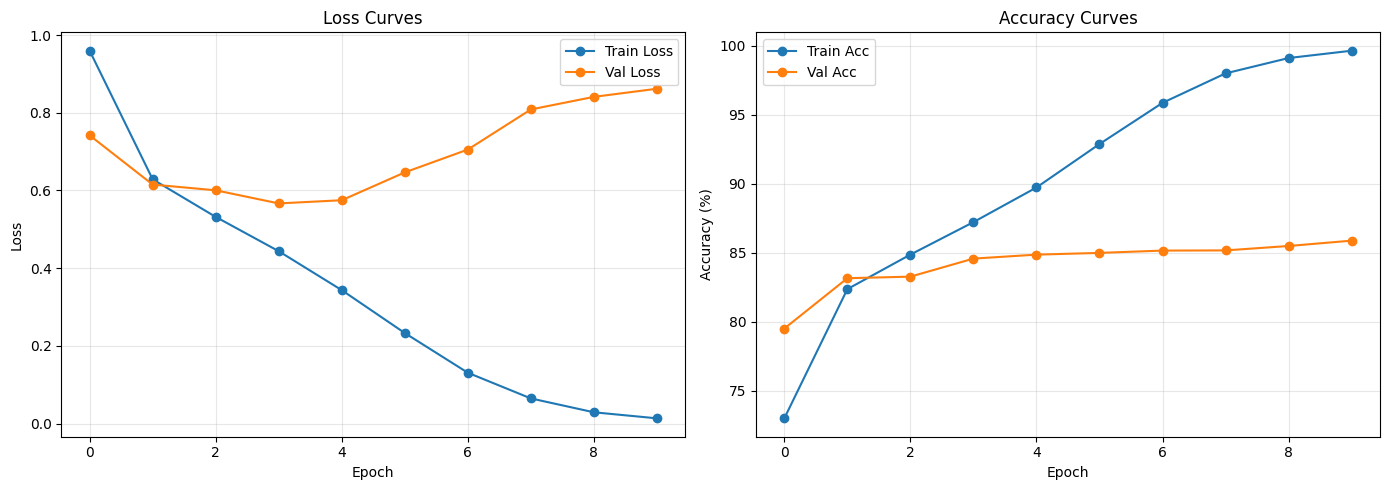

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
categories = []
for idx, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    categories.append(class_name)

models = ['best_model']
for model_name in models:
    checkpoint = torch.load(f'{model_name}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded {model_name} from epoch {checkpoint['epoch']+1} (Val Acc: {checkpoint['val_acc']:.2f}%)")

    test_loss, test_acc, test_preds, test_labels = validate_one_epoch(
        model, test_loader, criterion, device
    )

    print(f"Test Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=categories, digits=4))
    print("="*40)

Loaded best_model from epoch 10 (Val Acc: 85.89%)


Validating: 100%|██████████| 469/469 [00:15<00:00, 30.85it/s]

Test Results:
Test Loss: 0.8467
Test Accuracy: 86.11%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6197    0.5540    0.5850       500
        airplane     0.8221    0.8500    0.8358       500
     alarm_clock     0.8436    0.9060    0.8737       500
       ambulance     0.9422    0.9460    0.9441       500
           angel     0.9049    0.8940    0.8994       500
animal_migration     0.7649    0.7420    0.7533       500
             ant     0.8848    0.9060    0.8953       500
           anvil     0.9044    0.9080    0.9062       500
           apple     0.9560    0.9560    0.9560       500
             arm     0.8785    0.8680    0.8732       500
       asparagus     0.8698    0.8820    0.8759       500
             axe     0.8980    0.9160    0.9069       500
        backpack     0.8738    0.9140    0.8935       500
          banana     0.9272    0.9420    0.9345       500
         bandage     0.8603    0.8500    0.8551     